<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
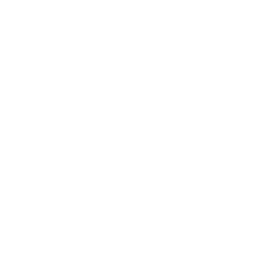
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identificación de regímenes de mercado</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finanzas cuantitativas / Gestión de activos &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Este ejemplo utiliza **PROC ACECLUS** para encontrar la estructura latente que separa los regímenes de mercado y luego agrupa sobre ella. A partir de 100 observaciones semanales de 10 características de mercado (rendimiento y volatilidad de la renta variable, diferenciales de crédito y de alto rendimiento, la curva 2a/10a, el dólar, las materias primas y una variación del VIX), ACECLUS estima una covarianza intrarrégimen aproximada *sin* utilizar ninguna etiqueta de régimen, y deriva variables canónicas a lo largo de las cuales los regímenes se separan.

Con el umbral P=0.02 el algoritmo converge en dos iteraciones y retiene **tres dimensiones canónicas**, que en conjunto explican toda la dispersión entre regímenes (proporciones de valores propios 57.8 %, 24.4 %, 17.8 %). Un umbral P=0.05 más laxo suaviza en exceso la covarianza y **colapsa la estructura a una sola dimensión**, una advertencia útil de que el umbral moldea materialmente el resultado.

Introducir las tres variables canónicas en **PROC FASTCLUS** (k=4) produce un ordenamiento nítido de las 100 semanas por severidad del estrés (R² global = 0.51, pseudo F = 33.2): un núcleo tranquilo de 62 semanas, un grupo de 22 semanas en recuperación/con volatilidad a la baja, un grupo de 12 semanas de estrés elevado y un grupo de 4 semanas de crisis profunda con diferenciales de alto rendimiento que promedian ~1,514 bps. Estas asignaciones se exportan para el condicionamiento posterior del riesgo de cartera.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Observaciones semanales de características de mercado en varias clases de activos | 100 |
| Variables: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

La serie se genera mediante un proceso de cambio de régimen de Markov de cinco estados (expansión alcista, ciclo tardío, aversión al riesgo, crisis, recuperación) con distribuciones de características condicionadas al régimen. Al ejecutarse sin licencia, la tabla de características se limita a las primeras 100 observaciones semanales (~2 años): una ventana dominada por el mercado alcista que también atraviesa una crisis breve y una recuperación. Los rendimientos semanales y los cambios de nivel sustituyen a los movimientos de precios de fin de semana; los diferenciales están en puntos básicos y la volatilidad es un índice tipo VIX.

---

In [1]:
/* --------------------------------------------------------
   Generate a weekly multi-asset market history with five
   embedded regime states driven by a Markov switching
   process. This worked example runs unlicensed, so the
   feature table below is capped at the first 100 weekly
   observations (~2 years) -- a bull-dominated window
   punctuated by a short crisis and recovery.
   -------------------------------------------------------- */
DATOS work.market_weekly;
    LLAMAR streaminit(42);
    /* 5 regimes: 1=Bull, 2=Late-Cycle, 3=Risk-Off, 4=Crisis, 5=Recovery */
    ARREGLO regime_names[5] $16 _temporary_
        ('BULL_EXPANSION' 'LATE_CYCLE' 'RISK_OFF_FLIGHT'
         'CRISIS' 'RECOVERY');
    RETENER current_regime 1;
    HACER week_id = 1 HASTA 5000;
        /* Markov regime switching */
        u = rand('uniform');
        SI current_regime = 1 ENTONCES HACER; /* Bull: long-lived */
            SI u > 0.97 ENTONCES current_regime = 2;
        END;
        SINO SI current_regime = 2 ENTONCES HACER; /* Late-cycle */
            SI u > 0.92 ENTONCES current_regime = 3;
        END;
        SINO SI current_regime = 3 ENTONCES HACER; /* Risk-off */
            SI u > 0.80 ENTONCES current_regime = 4;
            SINO SI u < 0.10 ENTONCES current_regime = 1;
        END;
        SINO SI current_regime = 4 ENTONCES HACER; /* Crisis: short */
            SI u > 0.75 ENTONCES current_regime = 5;
        END;
        SINO SI current_regime = 5 ENTONCES HACER; /* Recovery */
            SI u > 0.85 ENTONCES current_regime = 1;
        END;
        regime_label = regime_names[current_regime];
        /* Regime-conditional feature distributions */
        SI current_regime = 1 ENTONCES HACER;  /* Bull */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        END;
        SINO SI current_regime = 2 ENTONCES HACER;  /* Late-cycle */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        END;
        SINO SI current_regime = 3 ENTONCES HACER;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        END;
        SINO SI current_regime = 4 ENTONCES HACER;  /* Crisis */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        END;
        SINO HACER;  /* Recovery */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        END;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        SI week_id = 1 ENTONCES vix_chg = 0;
        SALIDA;
    END;
    ELIMINAR u;
    RENOMBRAR credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
EJECUTAR;

NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline market feature distributions by regime
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.market_weekly n mean std MIN MAX;
    CLASE regime_label;
    VAR eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
EJECUTAR;

                                                  The MEANS Procedure

                                           Analysis Variable : EQ_RETURN_PCT

        REGIME_LABEL             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        BULL_EXPANSION              28      0.2860000      1.0226518     -1.5980000      2.2150000
        CRISIS                      12     -2.3403333      3.9436692     -8.0160000      3.7360000
        LATE_CYCLE                  39      0.0364359      1.9733801     -4.6010000      3.7030000
        RECOVERY                     4      0.0077500      1.5951747     -0.8330000      2.4000000
        RISK_OFF_FLIGHT             17     -0.8447059      1.2832441     -3.3850000      1.1810000
        ------------------------------------------------------------------------------------------

                                             Analysis Vari

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


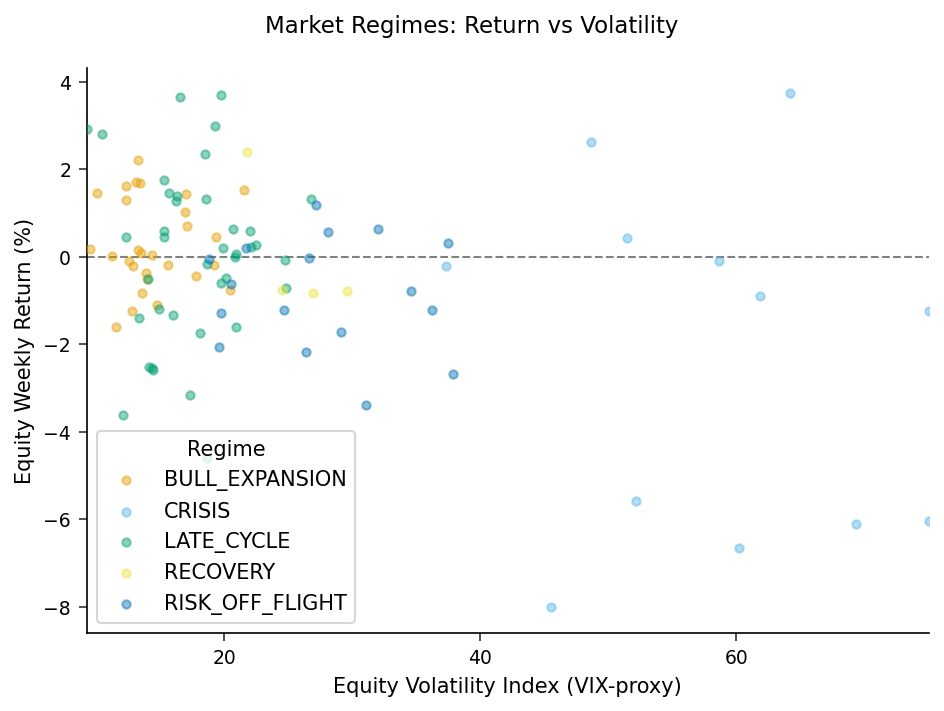

In [3]:
/* --------------------------------------------------------
   Equity return vs volatility index by regime label
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS ETIQUETA='Equity Volatility Index (VIX-proxy)';
    YAXIS ETIQUETA='Equity Weekly Return (%)';
    keylegend / TÍTULO='Regime';
    TÍTULO 'Market Regimes: Return vs Volatility';
EJECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Approximate within-regime covariance estimation.
   ACECLUS estimates the pooled within-cluster covariance
   without knowing the cluster labels, then derives
   canonical variables that separate the regimes. P=0.02
   sets the pairwise-distance threshold: only the closest
   ~2% of observation pairs are treated as same-regime.
   -------------------------------------------------------- */
PROCEDIMIENTO aceclus DATOS=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VAR eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
EJECUTAR;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0

NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Sensitivity check at P=0.05 -- a looser same-regime
   threshold pulls in more pairs, inflating the estimated
   within-regime covariance. Compare the canonical
   structure (eigenvalues and retained dimensions) against
   the P=0.02 solution.
   -------------------------------------------------------- */
PROCEDIMIENTO aceclus DATOS=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VAR eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
EJECUTAR;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0

NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-means on the ACECLUS canonical variables. ACECLUS
   retained three canonical dimensions (Can1-Can3), so the
   clustering runs on those. Four clusters target the four
   well-populated market states.
   -------------------------------------------------------- */
PROCEDIMIENTO FASTCLUS DATOS=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VAR can1 can2 can3;
EJECUTAR;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    

NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                         Regime Cluster vs Actual Regime Label                                          

                                                   The FREQ Procedure

Table of CLUSTER by REGIME_LABEL

CLUSTER | BULL_EXPANSION |         CRISIS |     LATE_CYCLE |       RECOVERY |RISK_OFF_FLIGHT |           Total
--------+----------------+----------------+----------------+----------------+----------------+----------------
1       |              2 |              4 |              2 |              0 |              4 |              12
        |           2.00 |           4.00 |           2.00 |           0.00 |           4.00 |           12.00
--------+----------------+----------------+----------------+----------------+----------------+----------------
2       |             21 |              3 |             28 |              3 |              7 |              62
        |          21.00 |           3.00 |          28.00 |           3.00 |           7.00 |           62

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


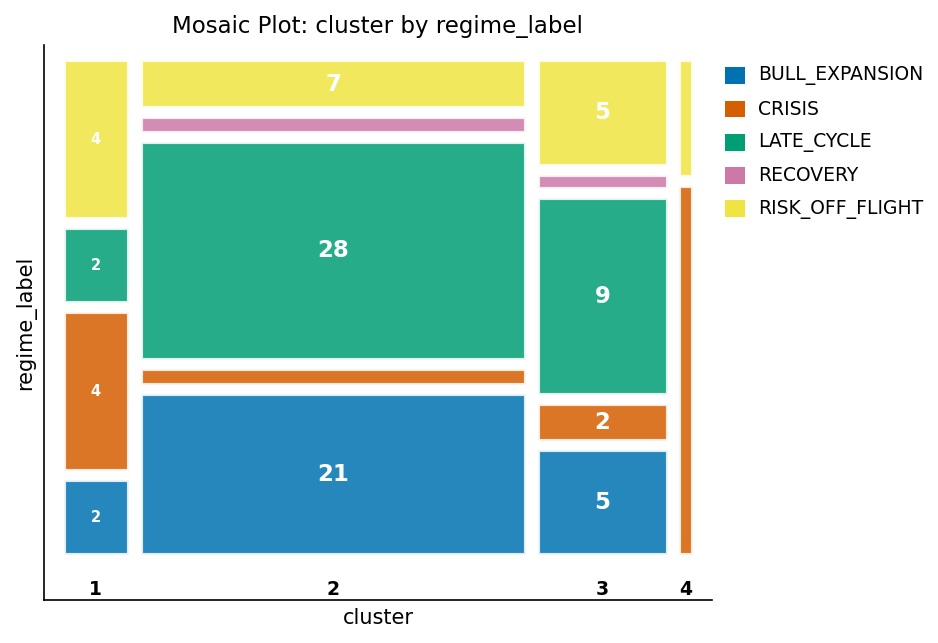

In [7]:
/* --------------------------------------------------------
   Validate assigned clusters against known
   regime labels from data generation
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    TÍTULO 'Regime Cluster vs Actual Regime Label';
EJECUTAR;

In [8]:
/* --------------------------------------------------------
   Profile regime feature means for interpretation
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.regime_assignments mean;
    CLASE CLUSTER;
    VAR eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
EJECUTAR;

                                         Regime Cluster vs Actual Regime Label                                          

                                                  The MEANS Procedure

                                           Analysis Variable : EQ_RETURN_PCT

                              N
        CLUSTER             Obs           Mean
        --------------------------------------
        1                    12     -2.0955000
        2                    62     -0.3638871
        3                    22      0.7421364
        4                     4     -0.4010000
        --------------------------------------

                                             Analysis Variable : EQ_VOL_IDX

                              N
        CLUSTER             Obs           Mean
        --------------------------------------
        1                    12     39.0125000
        2                    62     20.3977419
        3                    22     20.4918182
        4              

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretación

**Estructura canónica de ACECLUS.** En la muestra de 100 semanas, PROC ACECLUS (P=0.02, umbral = 2.578941) convergió en dos iteraciones y produjo tres variables canónicas. Sus valores propios de `Inv(ACE)*(COV-ACE)` son 0.0219, 0.0093 y 0.0067, es decir, proporciones de 57.8 %, 24.4 % y 17.8 % (acumulado 100 %). El primer eje canónico porta el contraste dominante de riesgo activado/desactivado; el segundo y el tercero lo refinan. Como las características de volatilidad de la renta variable y los diferenciales comovilizan fuertemente, ACECLUS incorpora esa variación compartida en la covarianza intrarrégimen de modo que los ejes canónicos reflejen una separación genuina entre regímenes en lugar de una escala común.

**Sensibilidad al umbral.** Volver a ejecutar con P=0.05 eleva el umbral de distancia a 2.899704, lo que sitúa 4,949 de los 4,950 pares de observaciones dentro del corte. La covarianza intrarrégimen estimada casi iguala entonces a la covarianza total, y la estructura canónica **colapsa a una sola dimensión** (un valor propio, 0.0096, al 100 %). Por tanto, las soluciones P=0.02 y P=0.05 *no* son intercambiables aquí: un umbral más laxo borra los ejes de régimen más finos, de modo que el umbral más estricto es la especificación más informativa para esta muestra.

**Agrupamiento sobre las variables canónicas.** PROC FASTCLUS (k=4) sobre Can1–Can3 da un R² global de 0.5089 y un pseudo F de 33.16. Can2 realiza la mayor parte del trabajo de separación (R² = 0.626), Can1 contribuye moderadamente (R² = 0.359) y Can3 no aporta esencialmente nada (R² = 0.000), coherente con que solo dos ejes portan señal fuerte. Los cuatro conglomerados se alinean como un gradiente de estrés de mercado:

| Conglomerado | n | Rend. medio RV | VIX medio | Diferencial HY medio | Variación media del VIX | Lectura |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Núcleo tranquilo (alcista / ciclo tardío) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | En recuperación, volatilidad a la baja |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Estrés elevado, volatilidad disparándose |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Crisis profunda, estrés crediticio extremo |

**Conglomerado frente a régimen verdadero.** La tabla cruzada muestra que los conglomerados no se corresponden uno a uno con las cinco etiquetas generadoras, algo esperable porque las etiquetas se solapan mucho en el espacio de características con este tamaño de muestra. El gran conglomerado tranquilo (62) absorbe la mayoría de las semanas alcistas (21) y de ciclo tardío (28); el conglomerado de crisis profunda (4) está compuesto casi por completo por las semanas de crisis más extremas (3 de 4). Así, los ejes canónicos organizan las semanas por *severidad*, no por etiqueta exacta, que es la señal más accionable para el condicionamiento del riesgo.

**Uso.** Las asignaciones semanales exportadas respaldan el condicionamiento táctico: reducir el riesgo y extender la duración a medida que las semanas migran hacia los conglomerados 1 y 4, y volver a asumir riesgo cuando regresan al núcleo tranquilo (conglomerado 2) o al grupo en recuperación (conglomerado 3).

---

In [9]:
/* --------------------------------------------------------
   Export weekly regime assignments for portfolio
   risk model conditioning and signal generation
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
EJECUTAR;

NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>